# Blind Image Deconvolution — Real Image Enhancement
### MATH 441 Convex Optimization

Old Optimization Function:
$$
\min_{k,\,\mathbf{u}}\;
\|k*\mathbf{u}-\mathbf{f}\|_2^2
+\lambda_1\underbrace{\|\nabla\mathbf{u}\|_1}_{\text{TV}}
+\lambda_2\underbrace{\|D\mathbf{u}\|_2^2}_{\text{Tikhonov}}
+\mu\underbrace{\|k\|_1}_{\text{kernel sparsity}}
\quad\text{s.t.}\quad k\geq0,\;\mathbf{1}^Tk=1,\;0\leq\mathbf{u}\leq255
$$

New Optimization Function:
$$
\min_{\mathbf{u}}\;
\|k*\mathbf{u}-\mathbf{f}\|_2^2
+\lambda_1\underbrace{\|\nabla\mathbf{u}\|_1}_{\text{TV}}
\quad\text{s.t.}\quad k\geq0,\;\mathbf{1}^Tk=1,\;0\leq\mathbf{u}\leq 1\; {\text{assuming normalized image values}}
$$


## Install CVXPY

In [1]:
pip install cvxpy

  Using cached cvxpy-1.8.2-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (9.6 kB)
  Using cached osqp-1.1.1-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.2 kB)
  Using cached clarabel-0.11.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.8 kB)
  Using cached scs-3.2.11-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (2.8 kB)
  Using cached highspy-1.14.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached cvxpy-1.8.2-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (1.4 MB)
Using cached clarabel-0.11.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.2 MB)
Using cached highspy-1.14.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (2.6 MB)
Using cached osqp-1.1.1-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (345 kB)
Using cached scs-3.2.11-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (12.1 MB)
 

## Importing Packages

In [2]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.signal import convolve2d

## Defining Functions

We would formulate a 2D Gaussian kernel and construct a sparse matrix K that performs 2D convolution

In the Sparse Matrix k definition code, it includes a section where we loop over every pixel and kernel. Then, we would check for the boundary layers.

In [6]:
def get_gaussian_kernel(size=5, sigma=1.0):
    ax = np.linspace(-(size - 1) / 2., (size - 1) / 2., size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-0.5 * (np.square(xx) + np.square(yy)) / np.square(sigma))
    return kernel / np.sum(kernel)

def create_sparse_blur_matrix(img_shape, kernel):
    M, N = img_shape
    kH, kW = kernel.shape
    pad_h, pad_w = kH // 2, kW // 2

    rows, cols, vals = [], [], []
    
    for i in range(M):
        for j in range(N):
            row_idx = i * N + j
            for ki in range(kH):
                for kj in range(kW):
                    ii = i + ki - pad_h
                    jj = j + kj - pad_w
                    
                    if 0 <= ii < M and 0 <= jj < N:
                        col_idx = ii * N + jj
                        rows.append(row_idx)
                        cols.append(col_idx)
                        vals.append(kernel[ki, kj])
                        
    return sp.csr_matrix((vals, (rows, cols)), shape=(M*N, M*N))

## Importing Image and Resizing to 128x128

In [7]:
from PIL import Image
import os
image_path = "kitten.jpg"

img_size = 128

if not os.path.exists(image_path):
    print(f"Error: {image_path} not found.")
    print("Please ensure your image is in the same folder as this script.")
    f_img = np.outer(np.linspace(0, 1, img_size), np.linspace(0, 1, img_size))
else:
    img = Image.open(image_path).convert('L')
    img = img.resize((img_size, img_size))
    f_img = np.array(img) / 255.0

## Define the Constant Kernel
* Unlike in our previous problem, we will assume $k$ is known and seek to optimize $u$.
* A sigma term is included for the blurriness of the image.

In [8]:
kernel_size = 9
sigma_value = 1.5
kernel = get_gaussian_kernel(size=kernel_size, sigma=sigma_value)
K_sparse = create_sparse_blur_matrix(f_img.shape, kernel)

f_vec = f_img.flatten()

## Formulate the Problem and Solve with CVXPY

We would include a Lambda_TV term for Regularization Weight.
* If the output image is too grainy, we would increase this Lambda_TV term.
* If the output image is too blocky, we would decrease this Lambda_TV term.

In [9]:
# print(f"Setting up optimization for {image_path}...")

U = cp.Variable((img_size, img_size))
U_vec = cp.vec(U)

LAMBDA_TV = 0.05 

obj = cp.Minimize(cp.sum_squares(K_sparse @ U_vec - f_vec) + LAMBDA_TV * cp.tv(U))

constraints = [U >= 0, U <= 1]

prob = cp.Problem(obj, constraints)

print("Solving... (This may take ~30-60 seconds)")
prob.solve(solver=cp.SCS, verbose=True)

u_recovered = U.value
u_recovered = u_recovered.T

/tmp/ipykernel_248/3330491314.py:4: FutureWarning: 
    You didn't specify the order of the vec expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  U_vec = cp.vec(U)
(CVXPY) Apr 20 06:19:31 AM: Your problem has 16384 variables, 32768 constraints, and 0 parameters.
(CVXPY) Apr 20 06:19:31 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 20 06:19:31 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 20 06:19:31 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 20 06:19:31 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 20 06:19:31 AM: Compiling problem (target solver=SCS).
(CVXPY) Apr 20 06:19:31 AM: Reduction chai

Setting up optimization for kitten.jpg...
Solving... (This may take ~30-60 seconds)
                                     CVXPY                                     
                                     v1.8.2                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Apr 20 06:19:31 AM: Applying reduction SCS
(CVXPY) Apr 20 06:19:32 AM: Finished problem compilation (took 9.744e-01 seconds).
(CVXPY) Apr 20 06:19:32 AM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 48897, constraints m: 97539
cones: 	  z: primal zero / dual free vars: 16384
	  l: linear vars: 32768
	  q: soc vars: 48387, qsize: 16129
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 1411221, nnz(P): 16384
------------------------------------------------------------------
 iter | p

(CVXPY) Apr 20 06:23:04 AM: Problem status: optimal
(CVXPY) Apr 20 06:23:04 AM: Optimal value: 8.444e+01
(CVXPY) Apr 20 06:23:04 AM: Compilation took 9.744e-01 seconds
(CVXPY) Apr 20 06:23:04 AM: Solver (including time spent in interface) took 2.120e+02 seconds


  2975| 2.14e-05  7.37e-06  2.66e-05  8.44e+01  1.02e+00  2.12e+02 
------------------------------------------------------------------
status:  solved
timings: total: 2.12e+02s = setup: 1.22e+01s + solve: 2.00e+02s
	 lin-sys: 1.69e+02s, cones: 3.69e+00s, accel: 9.43e-01s
------------------------------------------------------------------
objective = 84.436500
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


## Visualize the Results

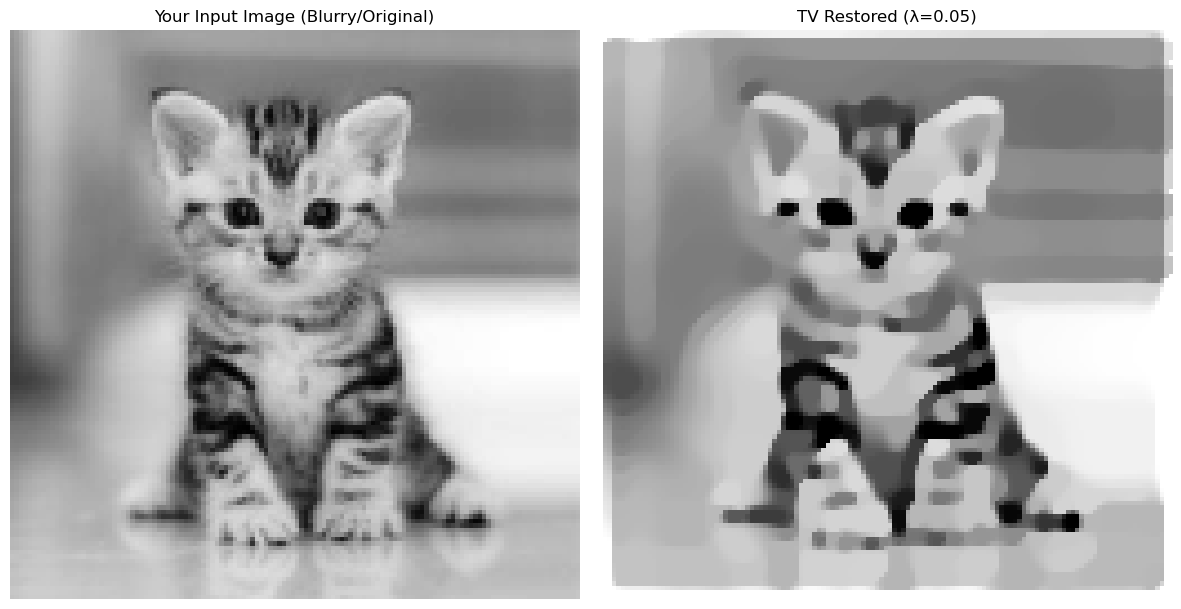

In [10]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(f_img, cmap='gray')
plt.title("Your Input Image (Blurry/Original)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(u_recovered, cmap='gray')
plt.title(f"TV Restored (λ={LAMBDA_TV})")
plt.axis('off')

plt.tight_layout()
plt.show()

## Reults at Lambda_TV = 0.1

In [11]:
LAMBDA_TV = 0.1

obj = cp.Minimize(cp.sum_squares(K_sparse @ U_vec - f_vec) + LAMBDA_TV * cp.tv(U))

constraints = [U >= 0, U <= 1]

prob = cp.Problem(obj, constraints)

print("Solving... (This may take ~30-60 seconds)")
prob.solve(solver=cp.SCS, verbose=True)

u_recovered = U.value
u_recovered = u_recovered.T

(CVXPY) Apr 20 06:24:21 AM: Your problem has 16384 variables, 32768 constraints, and 0 parameters.
(CVXPY) Apr 20 06:24:21 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 20 06:24:21 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 20 06:24:21 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 20 06:24:21 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 20 06:24:21 AM: Compiling problem (target solver=SCS).
(CVXPY) Apr 20 06:24:21 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Apr 20 06:24:21 AM: Applying reduction Dcp2Cone
(CVXPY) Apr 20 06:24:21 AM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 20 06:24:21 AM: Applying reduction ConeMatrixStuffing


Solving... (This may take ~30-60 seconds)
                                     CVXPY                                     
                                     v1.8.2                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Apr 20 06:24:21 AM: Applying reduction SCS
(CVXPY) Apr 20 06:24:22 AM: Finished problem compilation (took 1.019e+00 seconds).
(CVXPY) Apr 20 06:24:22 AM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 48897, constraints m: 97539
cones: 	  z: primal zero / dual free vars: 16384
	  l: linear vars: 32768
	  q: soc vars: 48387, qsize: 16129
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 1411221, nnz(P): 16384
------------------------------------------------------------------
 iter | p

(CVXPY) Apr 20 06:29:08 AM: Problem status: optimal
(CVXPY) Apr 20 06:29:08 AM: Optimal value: 1.174e+02
(CVXPY) Apr 20 06:29:08 AM: Compilation took 1.019e+00 seconds
(CVXPY) Apr 20 06:29:08 AM: Solver (including time spent in interface) took 2.865e+02 seconds


  4175| 1.97e-05  4.35e-06  6.14e-05  1.17e+02  1.01e+00  2.87e+02 
------------------------------------------------------------------
status:  solved
timings: total: 2.87e+02s = setup: 1.27e+01s + solve: 2.74e+02s
	 lin-sys: 2.40e+02s, cones: 5.01e+00s, accel: 1.34e+00s
------------------------------------------------------------------
objective = 117.392097
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


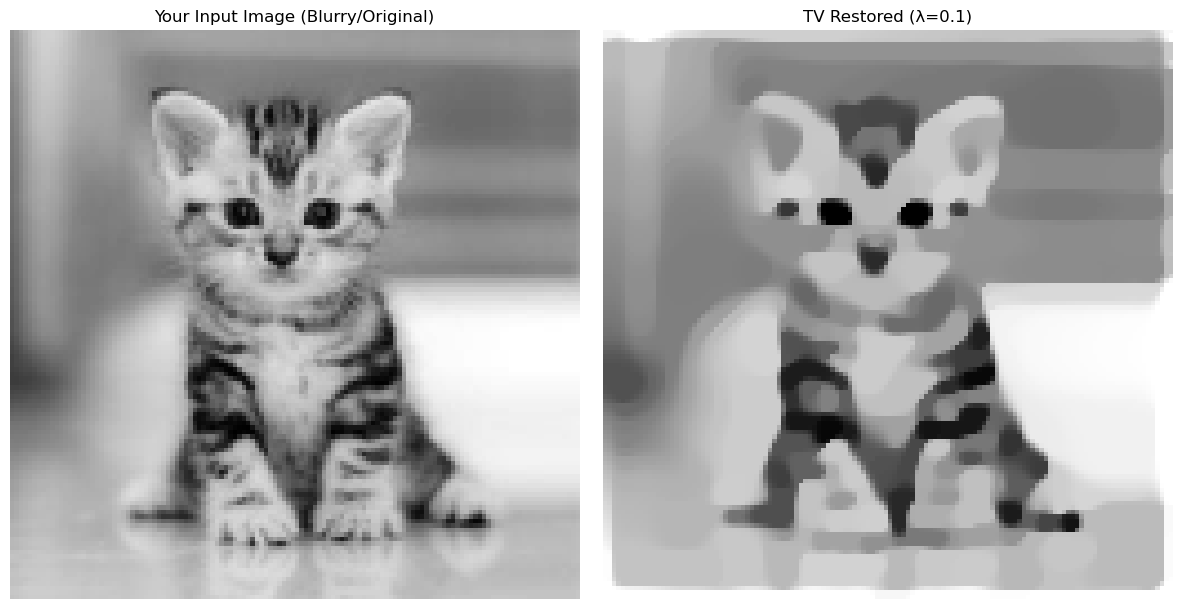

In [12]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(f_img, cmap='gray')
plt.title("Your Input Image (Blurry/Original)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(u_recovered, cmap='gray')
plt.title(f"TV Restored (λ={LAMBDA_TV})")
plt.axis('off')

plt.tight_layout()
plt.show()